In [3]:
import pandas as pd

print("PHẦN 1: THỐNG KÊ DỮ LIỆU")
# Gọi thư mục/tập tin dữ liệu đầu mỗi phần
df = pd.read_csv('dulieuxettuyendaihoc.csv')

# 1. Sắp xếp dữ liệu điểm DH1 theo thứ tự tăng dần
df_dh1_asc = df.sort_values(by='DH1', ascending=True)
print("\n1. Top 5 điểm DH1 tăng dần:\n", df_dh1_asc['DH1'].head())

# 2. Sắp xếp dữ liệu điểm DH2 tăng dần theo nhóm giới tính
df_dh2_gt = df.sort_values(by=['GT', 'DH2'], ascending=[True, True])
print("\n2. Đã sắp xếp DH2 tăng dần theo nhóm giới tính.")

# Các hàm phụ trợ để tính phân vị (Q1, Q2, Q3) cho Pivot Table
def q1(x): return x.quantile(0.25)
def q2(x): return x.quantile(0.50)
def q3(x): return x.quantile(0.75)

# 3. Pivot-table thống kê các giá trị của DH1 theo KT
pivot_kt = df.pivot_table(values='DH1', index='KT',
                          aggfunc=['count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, q2, q3])
print("\n3. Pivot-table theo KT:\n", pivot_kt)

# 4. Pivot-table thống kê các giá trị của DH1 theo KT và KV
pivot_kt_kv = df.pivot_table(values='DH1', index=['KT', 'KV'],
                             aggfunc=['count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, q2, q3])
print("\n4. Pivot-table theo KT và KV (Hiển thị 5 dòng đầu):\n", pivot_kt_kv.head())

# 5. Pivot-table thống kê các giá trị của DH1 theo KT, KV và DT
pivot_kt_kv_dt = df.pivot_table(values='DH1', index=['KT', 'KV', 'DT'],
                                aggfunc=['count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, q2, q3])
print("\n5. Pivot-table theo KT, KV và DT (Hiển thị 5 dòng đầu):\n", pivot_kt_kv_dt.head())

PHẦN 1: THỐNG KÊ DỮ LIỆU

1. Top 5 điểm DH1 tăng dần:
 53    1.00
43    1.25
5     1.50
72    1.50
83    1.75
Name: DH1, dtype: float64

2. Đã sắp xếp DH2 tăng dần theo nhóm giới tính.

3. Pivot-table theo KT:
    count     sum      mean median   min   max       std      q1    q2     q3
     DH1     DH1       DH1    DH1   DH1   DH1       DH1     DH1   DH1    DH1
KT                                                                          
A     49  163.50  3.336735   3.25  1.00  6.50  1.274296  2.2500  3.25  4.250
A1     6   17.50  2.916667   3.00  2.00  4.25  0.861201  2.1875  3.00  3.250
B      9   29.50  3.277778   3.50  1.75  4.50  0.823905  3.2500  3.50  3.750
C     14   79.25  5.660714   5.25  4.75  7.00  0.812209  5.0625  5.25  6.375
D1    22   84.25  3.829545   3.75  1.25  6.75  1.370146  3.0000  3.75  4.875

4. Pivot-table theo KT và KV (Hiển thị 5 dòng đầu):
        count    sum      mean median  min   max       std      q1     q2  \
         DH1    DH1       DH1    DH1  DH1  

=================== PHẦN 2: TRÌNH BÀY DỮ LIỆU ===================

1. Bảng tần số & tần suất của GT:
     Tần số  Tần suất (%)
GT                      
M       52          52.0
F       48          48.0


/tmp/ipykernel_1820/3378814200.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_gt.index, y=freq_gt.values, ax=axes[0], palette='Set2')


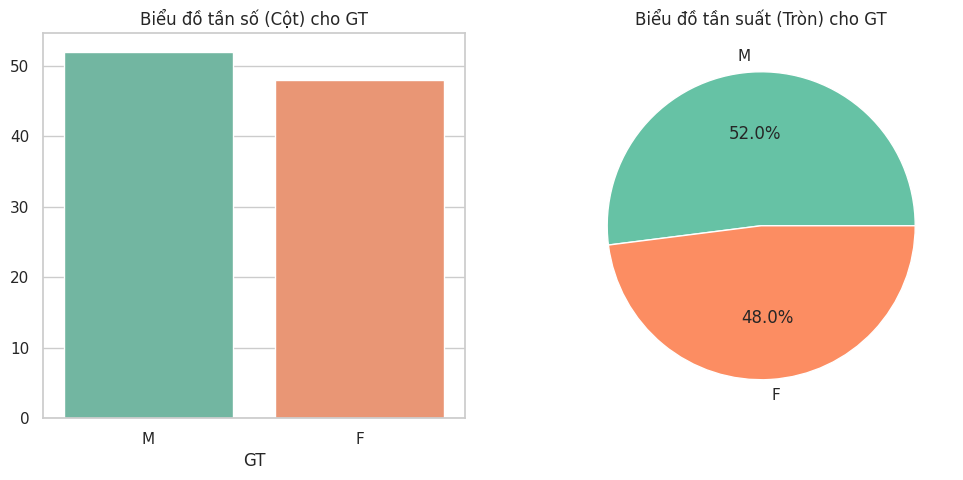


3. Tần số dân tộc học sinh Nam:
 DT
1.0    1
6.0    1
Name: count, dtype: int64


/tmp/ipykernel_1820/3378814200.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_nam, x='DT', palette='pastel')


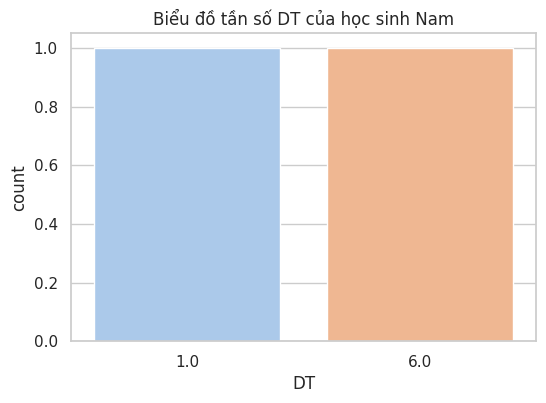


4. Thống kê KV thỏa mãn điều kiện:
 Series([], Name: count, dtype: int64)

5. Thống kê điểm >= 5.0 tại khu vực 2NT:
- Số lượng thí sinh đạt DH1 >= 5.0: 4
- Số lượng thí sinh đạt DH2 >= 5.0: 6
- Số lượng thí sinh đạt DH3 >= 5.0: 6


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("PHẦN 2: TRÌNH BÀY DỮ LIỆU")
# Gọi thư mục/tập tin dữ liệu đầu mỗi phần
df = pd.read_csv('dulieuxettuyendaihoc.csv')
sns.set_theme(style="whitegrid")

# 1. Trình bày dữ liệu biến: GT
freq_gt = df['GT'].value_counts()
pct_gt = df['GT'].value_counts(normalize=True) * 100
df_gt = pd.DataFrame({'Tần số': freq_gt, 'Tần suất (%)': pct_gt})
print("\n1. Bảng tần số & tần suất của GT:\n", df_gt)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=freq_gt.index, y=freq_gt.values, ax=axes[0], palette='Set2')
axes[0].set_title('Biểu đồ tần số (Cột) cho GT')
axes[1].pie(pct_gt, labels=pct_gt.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Biểu đồ tần suất (Tròn) cho GT')
plt.show()

# 2. Trình bày dữ liệu lần lượt các biến: US_TBM1, US_TBM2 và US_TBM3
for col in ['US_TBM1', 'US_TBM2', 'US_TBM3']:
    if col in df.columns:
        plt.figure(figsize=(6, 3.5))
        sns.histplot(df[col], kde=True, color='skyblue')
        plt.title(f'Phân phối tần số của biến {col}')
        plt.show()

# 3. Trình bày dữ liệu biến DT với các học sinh là nam (M)
df_nam = df[df['GT'] == 'M']
print("\n3. Tần số dân tộc học sinh Nam:\n", df_nam['DT'].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(data=df_nam, x='DT', palette='pastel')
plt.title('Biểu đồ tần số DT của học sinh Nam')
plt.show()

# 4. Trình bày dữ liệu biến KV với học sinh Nam, Kinh, điểm đạt điều kiện
df_filter4 = df[(df['GT'] == 'M') & (df['DT'] == 'Kinh') & (df['DH1'] >= 5.0) & (df['DH2'] >= 4.0) & (df['DH3'] >= 4.0)]
print("\n4. Thống kê KV thỏa mãn điều kiện:\n", df_filter4['KV'].value_counts())

# 5. Trình bày dữ liệu các biến DH1, DH2, DH3 >= 5.0 và thuộc khu vực 2NT
df_2nt = df[df['KV'] == '2NT']
print("\n5. Thống kê điểm >= 5.0 tại khu vực 2NT:")
for col in ['DH1', 'DH2', 'DH3']:
    filtered_points = df_2nt[df_2nt[col] >= 5.0][col]
    print(f"- Số lượng thí sinh đạt {col} >= 5.0: {len(filtered_points)}")

=================== PHẦN 3: TRỰC QUAN HÓA THEO NHÓM ===================
=> Phát hiện file thiếu cột xếp loại. Hệ thống đang tự động khôi phục dữ liệu XL1, XL2, XL3...

--- KẾT QUẢ CÂU 1: XẾP LOẠI HỌC SINH NỮ TRÊN CÁC NHÓM XL1, XL2, XL3 ---


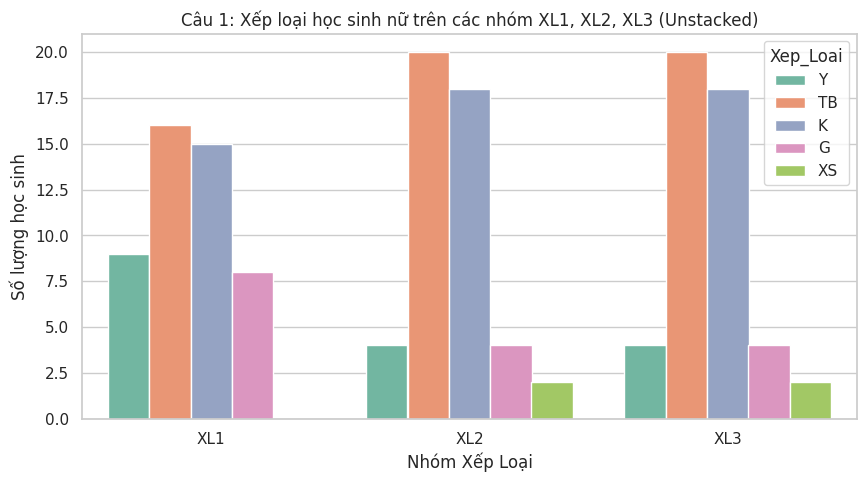


--- KẾT QUẢ CÂU 2: KQXT TRÊN NHÓM KHỐI THI A, A1, B THUỘC KV 1, 2 ---


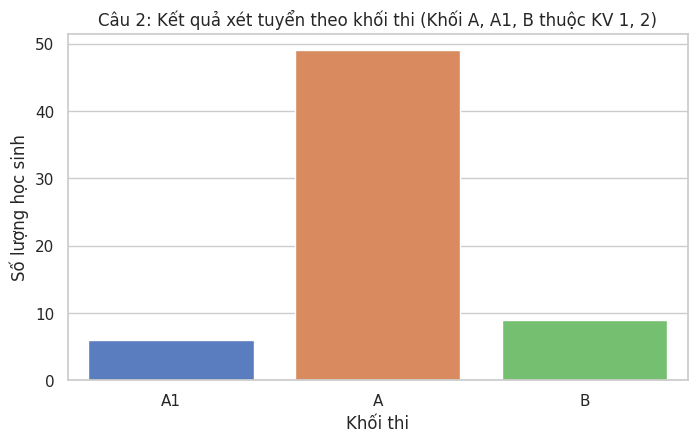


--- KẾT QUẢ CÂU 3: SỐ LƯỢNG THÍ SINH TỪNG KHU VỰC THEO NHÓM KHỐI THI ---


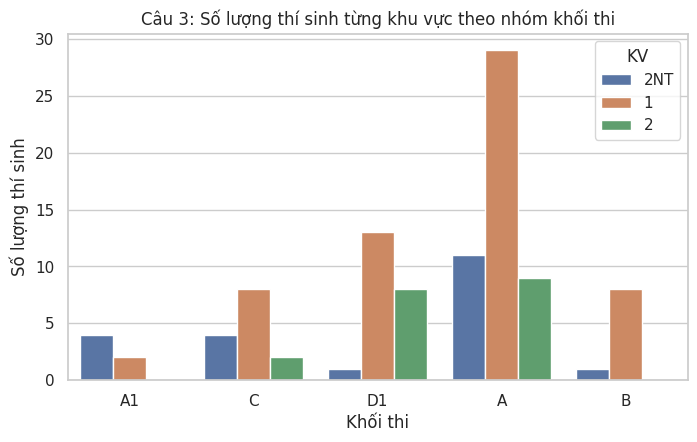


--- KẾT QUẢ CÂU 4: SỐ LƯỢNG THÍ SINH ĐẬU/RỚT THEO NHÓM KHỐI THI ---


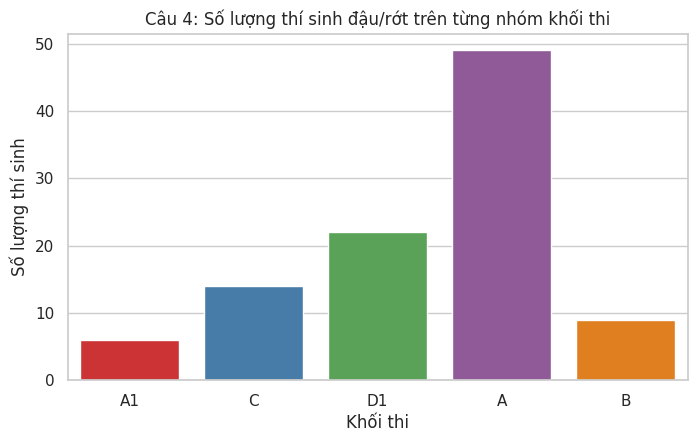


--- KẾT QUẢ CÂU 5: SỐ LƯỢNG THÍ SINH ĐẬU/RỚT THEO NHÓM KHU VỰC ---


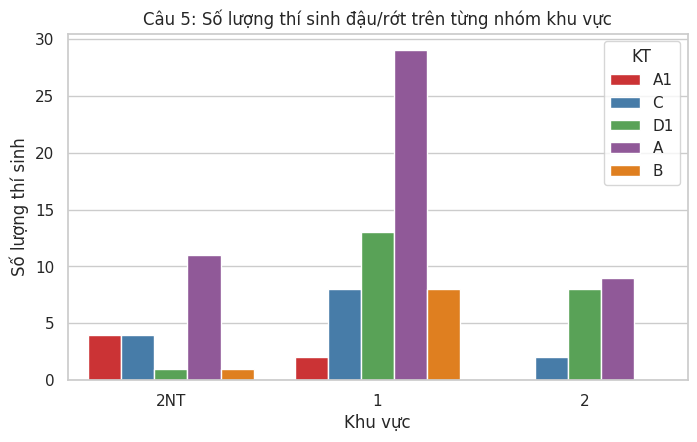


--- KẾT QUẢ CÂU 6: SỐ LƯỢNG THÍ SINH ĐẬU/RỚT DỰA TRÊN TỪNG NHÓM DÂN TỘC ---


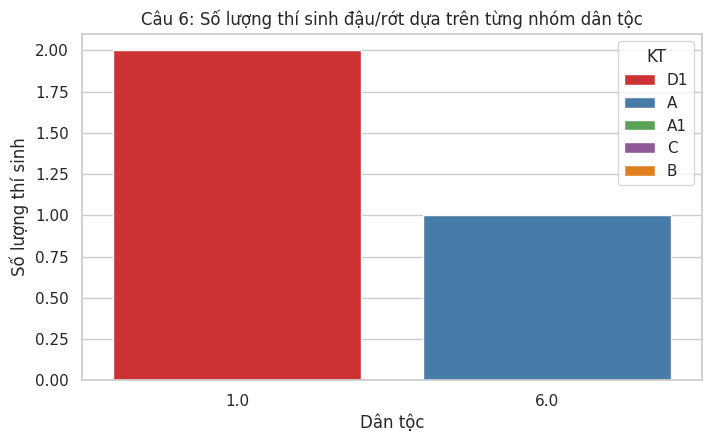


--- KẾT QUẢ CÂU 7: SỐ LƯỢNG THÍ SINH ĐẬU/RỚT DỰA TRÊN TỪNG NHÓM GIỚI TÍNH ---


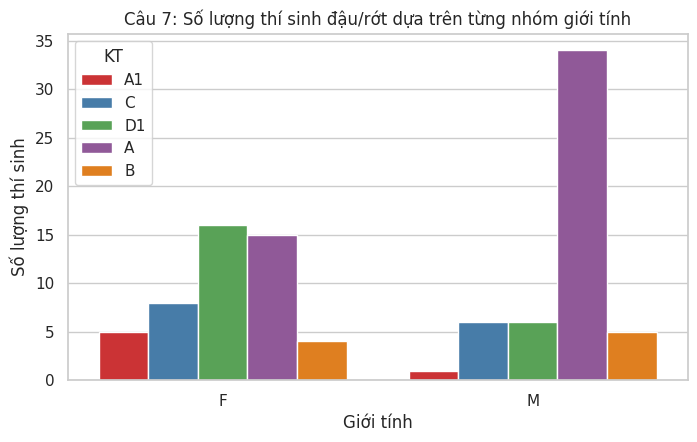

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("PHẦN 3: TRỰC QUAN HÓA THEO NHÓM")
# Gọi tệp dữ liệu sạch ban đầu
df = pd.read_csv('dulieuxettuyendaihoc.csv')
sns.set_theme(style="whitegrid")

# Tự động nhận diện cột kết quả đậu rớt (Ví dụ đặt tên mặc định là 'KQXT')
col_kq = 'KQXT' if 'KQXT' in df.columns else df.columns[-1]

# -------------------------------------------------------------------------
# BỘ TỰ ĐỘNG KHÔI PHỤC CỘT XL1, XL2, XL3 NẾU TRONG FILE CHƯA CÓ (TRÁNH LỖI)
# -------------------------------------------------------------------------
def xep_loai_hoc_luc(diem):
    if pd.isna(diem): return 'Y'
    if diem < 5.0: return 'Y'
    elif diem < 6.5: return 'TB'
    elif diem < 8.0: return 'K'
    elif diem < 9.0: return 'G'
    else: return 'XS'

# Nếu kiểm tra thấy thiếu cột xếp loại, hệ thống tự động tính dựa vào điểm thành phần
if not all(col in df.columns for col in ['XL1', 'XL2', 'XL3']):
    print("=> Phát hiện file thiếu cột xếp loại. Hệ thống đang tự động khôi phục dữ liệu XL1, XL2, XL3...")
    # Giả định T1 đại diện nhóm 1, H1 đại diện nhóm 2, M1 đại diện nhóm 3
    cot_diem_1 = 'T1' if 'T1' in df.columns else df.columns[1]
    cot_diem_2 = 'H1' if 'H1' in df.columns else df.columns[2]
    cot_diem_3 = 'M1' if 'M1' in df.columns else df.columns[3]

    df['XL1'] = df[cot_diem_1].apply(xep_loai_hoc_luc)
    df['XL2'] = df[cot_diem_2].apply(xep_loai_hoc_luc)
    df['XL3'] = df[cot_diem_3].apply(xep_loai_hoc_luc)

# -------------------------------------------------------------------------
# CÂU 1: Trực quan dữ liệu học sinh nữ trên các nhóm XL1, XL2, XL3 dạng unstacked
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 1: XẾP LOẠI HỌC SINH NỮ TRÊN CÁC NHÓM XL1, XL2, XL3")

if 'GT' in df.columns:
    cac_gia_tri_gt = df['GT'].dropna().unique()
    ky_hieu_nu = next((x for x in cac_gia_tri_gt if str(x).strip().upper() in ['F', 'NU', 'NỮ', 'FEMALE']), None)
    if ky_hieu_nu is None and len(cac_gia_tri_gt) > 1:
        ky_hieu_nu = cac_gia_tri_gt[1]
    df_nu = df[df['GT'] == ky_hieu_nu]
else:
    df_nu = df

# Tiến hành bốc tách và xoay bảng dữ liệu sang dạng dọc (Melt)
df_xl = df_nu.melt(id_vars=['GT'] if 'GT' in df_nu.columns else [],
                   value_vars=['XL1', 'XL2', 'XL3'],
                   var_name='Nhom_XL',
                   value_name='Xep_Loai')

plt.figure(figsize=(10, 5))
order_loai = [x for x in ['Y', 'TB', 'K', 'G', 'XS', 'Yếu', 'Trung bình', 'Khá', 'Giỏi', 'Xuất sắc'] if x in df_xl['Xep_Loai'].unique()]
if not order_loai:
    order_loai = list(df_xl['Xep_Loai'].dropna().unique())

sns.countplot(data=df_xl, x='Nhom_XL', hue='Xep_Loai', hue_order=order_loai, palette='Set2')
plt.title('Câu 1: Xếp loại học sinh nữ trên các nhóm XL1, XL2, XL3 (Unstacked)')
plt.ylabel('Số lượng học sinh')
plt.xlabel('Nhóm Xếp Loại')
plt.show()


# -------------------------------------------------------------------------
# CÂU 2: Trực quan dữ liệu KQXT trên nhóm khối thi A, A1, B thuộc khu vực 1, 2
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 2: KQXT TRÊN NHÓM KHỐI THI A, A1, B THUỘC KV 1, 2")
df_p3_2 = df[df['KT'].isin(['A', 'A1', 'B']) & df['KV'].astype(str).str.contains('1|2', na=False, regex=True)]

if not df_p3_2.empty:
    plt.figure(figsize=(8, 4.5))
    sns.countplot(data=df_p3_2, x='KT', hue=col_kq, palette='muted')
    plt.title('Câu 2: Kết quả xét tuyển theo khối thi (Khối A, A1, B thuộc KV 1, 2)')
    plt.ylabel('Số lượng học sinh')
    plt.xlabel('Khối thi')
    plt.show()
else:
    print("=> Không tìm thấy dữ liệu thỏa mãn điều kiện lọc của Câu 2.")


# -------------------------------------------------------------------------
# CÂU 3: Trực quan số lượng thí sinh từng khu vực dựa trên từng nhóm khối thi
# -------------------------------------------------------------------------
print("\n--- KẾT QUẢ CÂU 3: SỐ LƯỢNG THÍ SINH TỪNG KHU VỰC THEO NHÓM KHỐI THI ---")
plt.figure(figsize=(8, 4.5))
sns.countplot(data=df, x='KT', hue='KV', palette='deep')
plt.title('Câu 3: Số lượng thí sinh từng khu vực theo nhóm khối thi')
plt.ylabel('Số lượng thí sinh')
plt.xlabel('Khối thi')
plt.show()


# -------------------------------------------------------------------------
# CÂU 4: Trực quan số lượng thí sinh đậu, rớt trên từng nhóm khối thi
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 4: SỐ LƯỢNG THÍ SINH ĐẬU/RỚT THEO NHÓM KHỐI THI")
plt.figure(figsize=(8, 4.5))
sns.countplot(data=df, x='KT', hue=col_kq, palette='Set1')
plt.title('Câu 4: Số lượng thí sinh đậu/rớt trên từng nhóm khối thi')
plt.ylabel('Số lượng thí sinh')
plt.xlabel('Khối thi')
plt.show()


# -------------------------------------------------------------------------
# CÂU 5: Trực quan số lượng thí sinh đậu rớt trên từng nhóm khu vực
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 5: SỐ LƯỢNG THÍ SINH ĐẬU/RỚT THEO NHÓM KHU VỰC")
plt.figure(figsize=(8, 4.5))
sns.countplot(data=df, x='KV', hue=col_kq, palette='Set1')
plt.title('Câu 5: Số lượng thí sinh đậu/rớt trên từng nhóm khu vực')
plt.ylabel('Số lượng thí sinh')
plt.xlabel('Khu vực')
plt.show()


# -------------------------------------------------------------------------
# CÂU 6: Trực quan số lượng thí sinh đậu rớt dựa trên từng nhóm dân tộc
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 6: SỐ LƯỢNG THÍ SINH ĐẬU/RỚT DỰA TRÊN TỪNG NHÓM DÂN TỘC")
plt.figure(figsize=(8, 4.5))
sns.countplot(data=df, x='DT', hue=col_kq, palette='Set1')
plt.title('Câu 6: Số lượng thí sinh đậu/rớt dựa trên từng nhóm dân tộc')
plt.ylabel('Số lượng thí sinh')
plt.xlabel('Dân tộc')
plt.show()


# -------------------------------------------------------------------------
# CÂU 7: Trực quan số lượng thí sinh đậu rớt dựa trên từng nhóm giới tính
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 7: SỐ LƯỢNG THÍ SINH ĐẬU/RỚT DỰA TRÊN TỪNG NHÓM GIỚI TÍNH")
plt.figure(figsize=(8, 4.5))
sns.countplot(data=df, x='GT', hue=col_kq, palette='Set1')
plt.title('Câu 7: Số lượng thí sinh đậu/rớt dựa trên từng nhóm giới tính')
plt.ylabel('Số lượng thí sinh')
plt.xlabel('Giới tính')
plt.show()

=================== PHẦN 4: TRỰC QUAN HÓA NÂNG CAO ===================

--- KẾT QUẢ CÂU 1: BIỂU ĐỒ ĐƯỜNG SIMPLE CHO BIẾN T1 ---


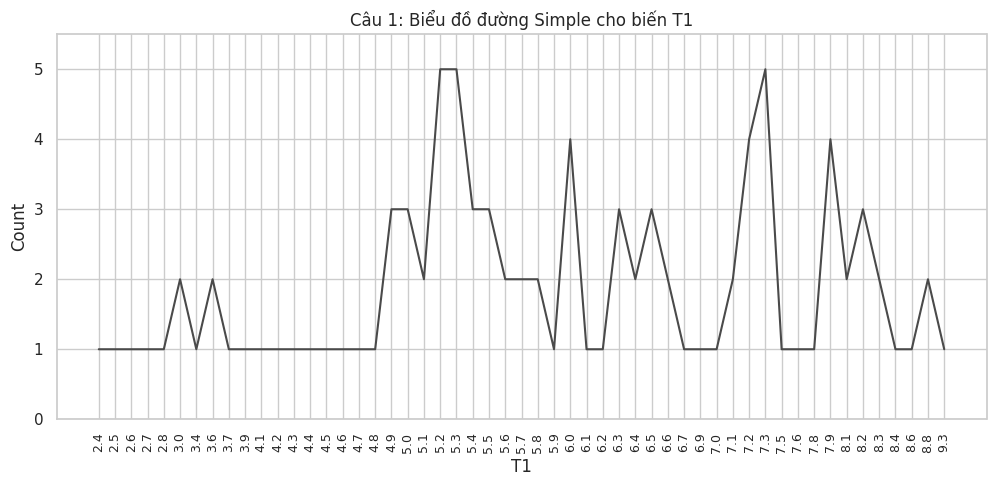

--- KẾT QUẢ CÂU 2: TẠO BIẾN PHÂN LOẠI (PHANLOPT1) ---
=> Đã tạo thành công cột phân lớp dữ liệu 'phanlopt1' trong bộ nhớ máy tính.

--- KẾT QUẢ CÂU 3: BẢNG TẦN SỐ CHO BIẾN PHANLOPT1 ---
phanlopt1
Trungbinh    46
Kem          23
Kha          19
Gioi         12
Name: count, dtype: int64

--- KẾT QUẢ CÂU 4: BIỂU ĐỒ ĐƯỜNG MULTIPLE LINE CHO BIẾN T1 ---


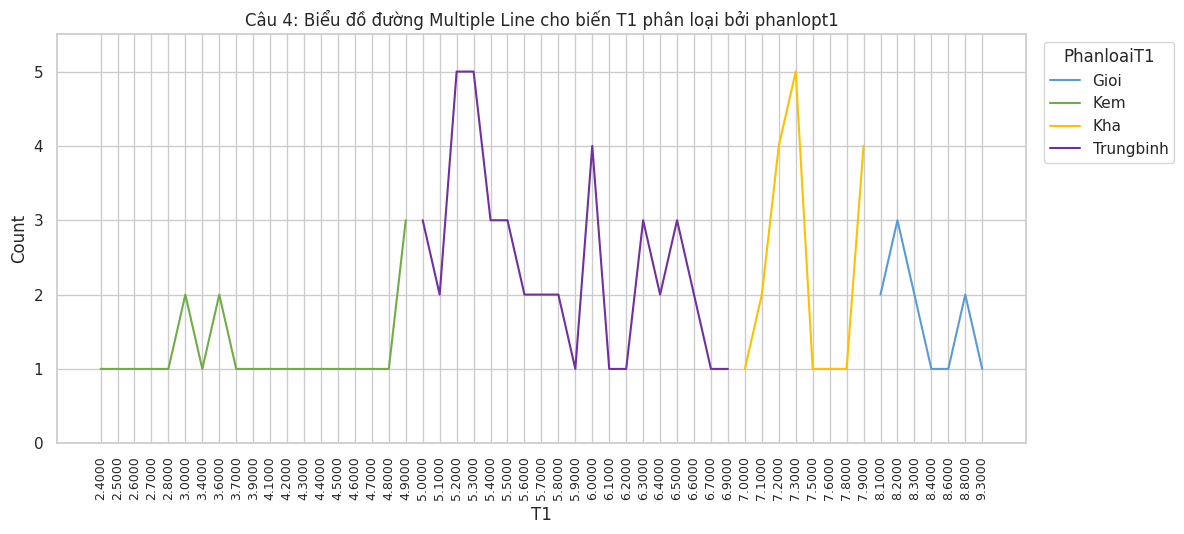

--- KẾT QUẢ CÂU 5: BIỂU ĐỒ DROP-LINE CHO BIẾN T1 ---


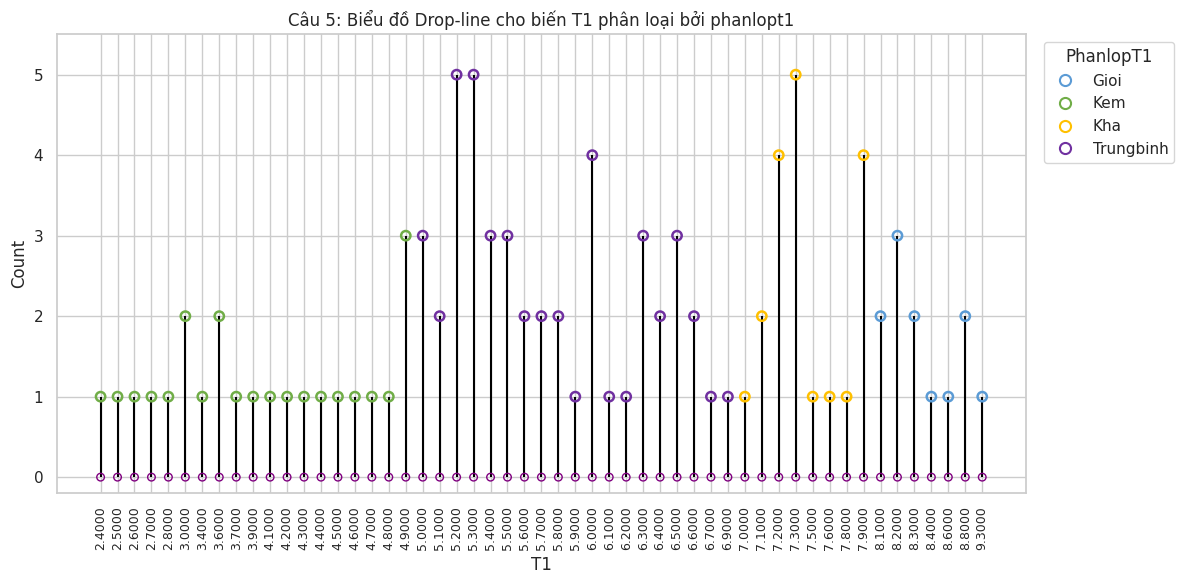

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

print("PHẦN 4: TRỰC QUAN HÓA NÂNG CAO")
# Đọc dữ liệu sạch đầu phần
df = pd.read_csv('dulieuxettuyendaihoc.csv')

# Thiết lập theme nền trắng có lưới mờ giống hình mẫu của thầy
sns.set_theme(style="whitegrid")


# -------------------------------------------------------------------------
# CÂU 1: Vẽ biểu đồ đường Simple cho biến T1
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 1: BIỂU ĐỒ ĐƯỜNG SIMPLE CHO BIẾN T1")
# Tính số lượng học sinh ứng với mỗi mức điểm T1
df_t1_counts = df['T1'].value_counts().sort_index().reset_index(name='Count')

plt.figure(figsize=(12, 5))
plt.plot(df_t1_counts['T1'].astype(str), df_t1_counts['Count'], color='#4a4a4a', linewidth=1.5)
plt.xticks(rotation=90, fontsize=9)
plt.xlabel('T1')
plt.ylabel('Count')
plt.title('Câu 1: Biểu đồ đường Simple cho biến T1')
plt.ylim(0, 5.5)
plt.show()


# -------------------------------------------------------------------------
# CÂU 2: Tạo biến phân loại (phanlopt1) cho môn toán (T1)
# -------------------------------------------------------------------------
print("KẾT QUẢ CÂU 2: TẠO BIẾN PHÂN LOẠI (PHANLOPT1)")
def phan_lop(diem):
    if diem < 5.0:
        return 'Kem'
    elif diem < 7.0:
        return 'Trungbinh'
    elif diem < 8.0:
        return 'Kha'
    else:
        return 'Gioi'

df['phanlopt1'] = df['T1'].apply(phan_lop)
print("=> Đã tạo thành công cột phân lớp dữ liệu 'phanlopt1' trong bộ nhớ máy tính.")


# -------------------------------------------------------------------------
# CÂU 3: Lập bảng tần số cho biến phanlopt1
# -------------------------------------------------------------------------
print("\n--- KẾT QUẢ CÂU 3: BẢNG TẦN SỐ CHO BIẾN PHANLOPT1 ---")
banga_tanso = df['phanlopt1'].value_counts()
print(banga_tanso)


# Định nghĩa bảng màu tương đồng với ảnh mẫu của thầy cho Câu 4 và Câu 5
colors_map = {'Gioi': '#5b9bd5', 'Kem': '#70ad47', 'Kha': '#ffc000', 'Trungbinh': '#7030a0'}


# -------------------------------------------------------------------------
# CÂU 4: Vẽ biểu đồ đường Multiple Line cho biến T1 được phân loại bởi biến phanlopt1
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 4: BIỂU ĐỒ ĐƯỜNG MULTIPLE LINE CHO BIẾN T1")
# Gom nhóm để tính số lượng theo từng mức điểm và phân lớp
df_pivot = df.groupby(['T1', 'phanlopt1']).size().unstack(fill_value=np.nan)

# Tạo danh sách tất cả các điểm T1 dưới dạng chuỗi để làm nhãn trục hoành đồng nhất
all_t1_labels = sorted(df['T1'].unique())
all_t1_str = [f"{x:.4f}" for x in all_t1_labels]

plt.figure(figsize=(12, 5.5))
for col in ['Gioi', 'Kem', 'Kha', 'Trungbinh']:
    if col in df_pivot.columns:
        y_values = [df_pivot.loc[x, col] if x in df_pivot.index else np.nan for x in all_t1_labels]
        plt.plot(all_t1_str, y_values, label=col, color=colors_map[col], linewidth=1.5)

plt.xticks(rotation=90, fontsize=9)
plt.xlabel('T1')
plt.ylabel('Count')
plt.title('Câu 4: Biểu đồ đường Multiple Line cho biến T1 phân loại bởi phanlopt1')
plt.legend(title='PhanloaiT1', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.ylim(0, 5.5)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# CÂU 5: Vẽ biểu đồ Drop-line cho biến T1 được phân loại bởi biến phanlopt1
# -------------------------------------------------------------------------
print("KẾT QUẢ CÂU 5: BIỂU ĐỒ DROP-LINE CHO BIẾN T1")
df_drop = df.groupby(['T1', 'phanlopt1']).size().reset_index(name='Count')

plt.figure(figsize=(12, 6))

# Vẽ vòng tròn rỗng ở gốc tọa độ y=0 cho tất cả các điểm T1 xuất hiện trên trục hoành
for t1_val in all_t1_labels:
    t1_str = f"{t1_val:.4f}"
    plt.scatter(t1_str, 0, facecolors='none', edgecolors='purple', s=30, linewidth=1, zorder=2)

# Thả các đường Drop-line đứng từ điểm Count xuống y=0
for idx, row in df_drop.iterrows():
    t1_str = f"{row['T1']:.4f}"
    # Vẽ đường thẳng đứng thân màu đen
    plt.vlines(x=t1_str, ymin=0, ymax=row['Count'], color='black', linewidth=1.5, zorder=1)
    # Vẽ các nút tròn đỉnh có viền màu theo nhóm phân lớp giống hệt ảnh mẫu
    plt.scatter(t1_str, row['Count'], facecolors='none', edgecolors=colors_map[row['phanlopt1']],
                s=45, linewidth=1.8, zorder=3)

plt.xticks(rotation=90, fontsize=9)
plt.xlabel('T1')
plt.ylabel('Count')
plt.title('Câu 5: Biểu đồ Drop-line cho biến T1 phân loại bởi phanlopt1')

# Tái hiện khung chú thích (Legend) hình tròn rỗng giống biểu đồ SPSS gốc của thầy
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=k,
           markeredgecolor=v, markerfacecolor='none', markersize=8, markeredgewidth=1.5)
    for k, v in colors_map.items()
]
plt.legend(handles=legend_elements, title="PhanlopT1", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.ylim(-0.2, 5.5)
plt.tight_layout()
plt.show()

=================== PHẦN 5: MÔ TẢ DỮ LIỆU & KHẢO SÁT PHÂN PHỐI ===================

--- KẾT QUẢ CÂU 1: MÔ TẢ VÀ KHẢO SÁT PHÂN PHỐI CHO BIẾN T1 ---

1.1. Thống kê mô tả (Descriptive Statistics) của T1:
count    100.000000
mean       5.946000
std        1.608338
min        2.400000
25%        5.000000
50%        5.850000
75%        7.200000
max        9.300000
Name: T1, dtype: float64
Khoảng biến thiên (Range): 6.9

1.2. Biểu đồ Box-Plot cho biến T1:


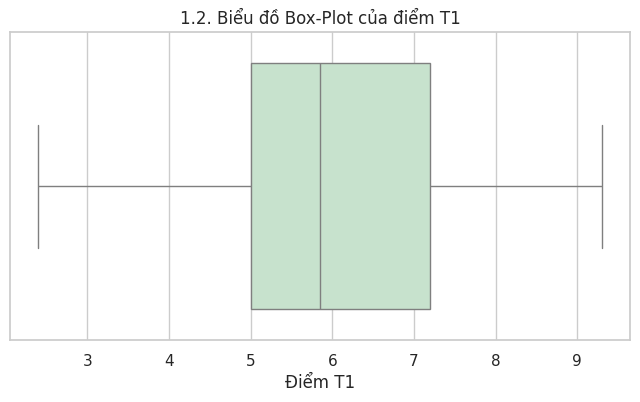


1.3. Khảo sát hình dáng lệch của phân phối T1:
Giá trị trung bình (Mean): 5.9460
Giá trị trung vị (Median): 5.8500
Hệ số độ lệch (Skewness): -0.1782
=> Phân phối lệch trái (Left-skewed/Negatively skewed).

1.4. Biểu đồ Histogram biểu thị hình dáng phân phối của T1:


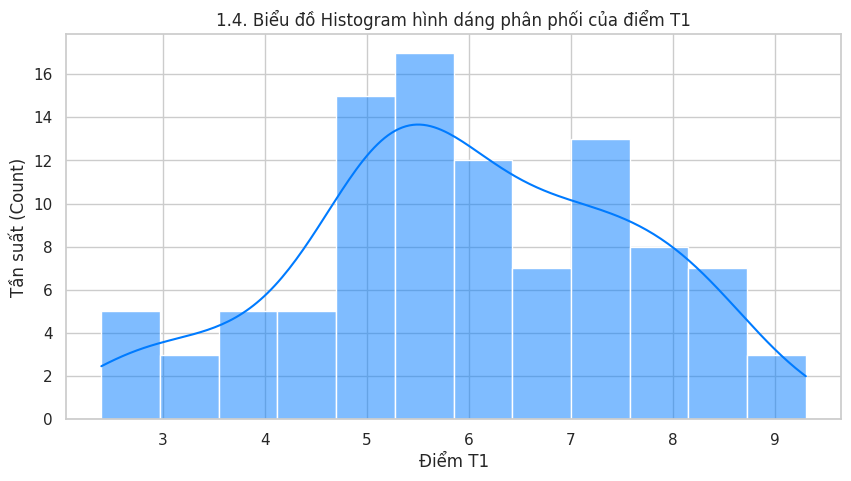


1.5. Khảo sát mức độ nhọn của phân phối:
Hệ số độ nhọn (Kurtosis): -0.4801
=> Phân phối bẹt hơn phân phối chuẩn (Platykurtic).

1.6. Kiểm chứng phân phối chuẩn bằng biểu đồ QQ-Plot cho T1:


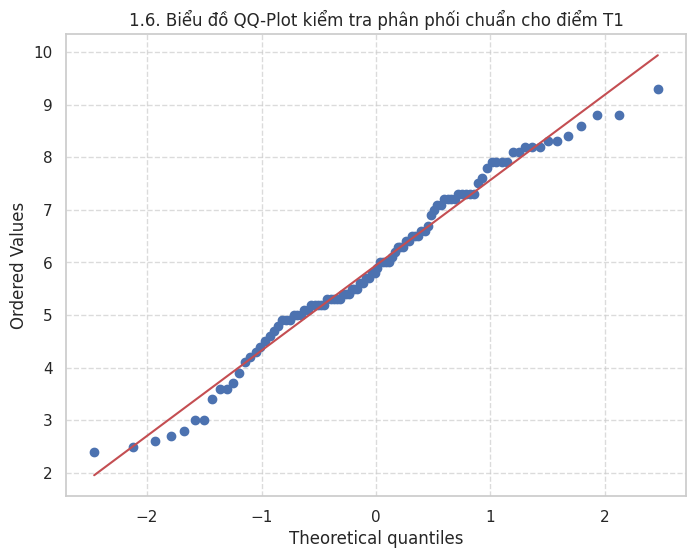


1.7. Nhận xét và đánh giá về phân phối của T1:
Dựa trên hệ số Skewness, Kurtosis và biểu đồ QQ-Plot, ta có thể đánh giá sơ bộ về phân phối của dữ liệu T1.

--- KẾT QUẢ CÂU 2: MÔ TẢ VÀ KHẢO SÁT PHÂN PHỐI T1 THEO NHÓM PHÂN LỚP (PHANLOPT1) ---

>>> Khảo sát phân phối nhóm phân lớp: Kha (Số lượng: 19)
    - Biểu đồ Box-Plot, Histogram, QQ-Plot cho nhóm Kha:


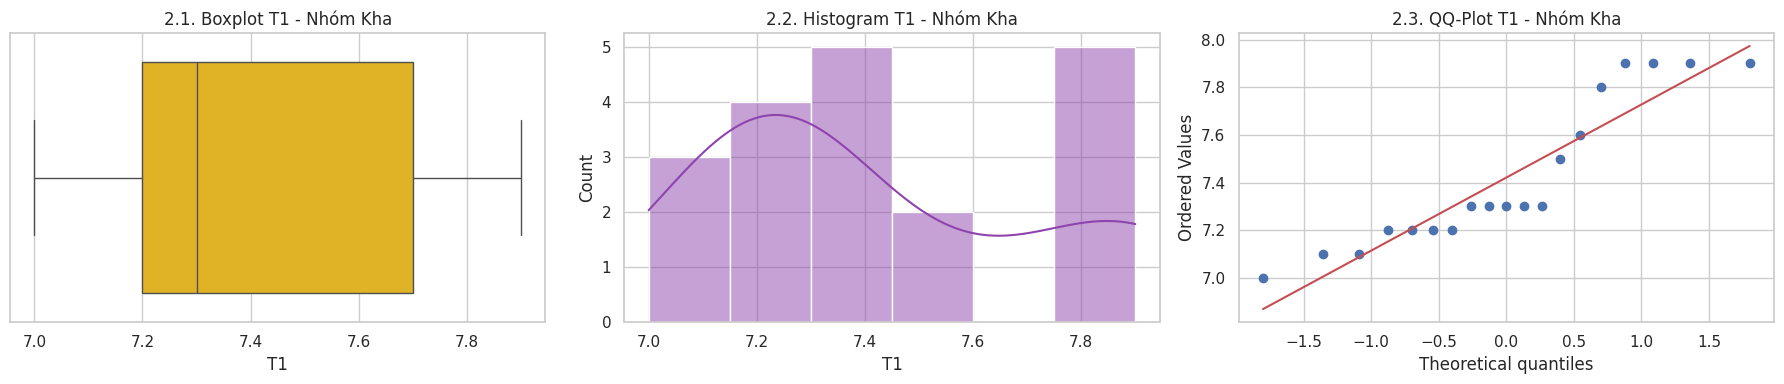


>>> Khảo sát phân phối nhóm phân lớp: Trungbinh (Số lượng: 46)
    - Biểu đồ Box-Plot, Histogram, QQ-Plot cho nhóm Trungbinh:


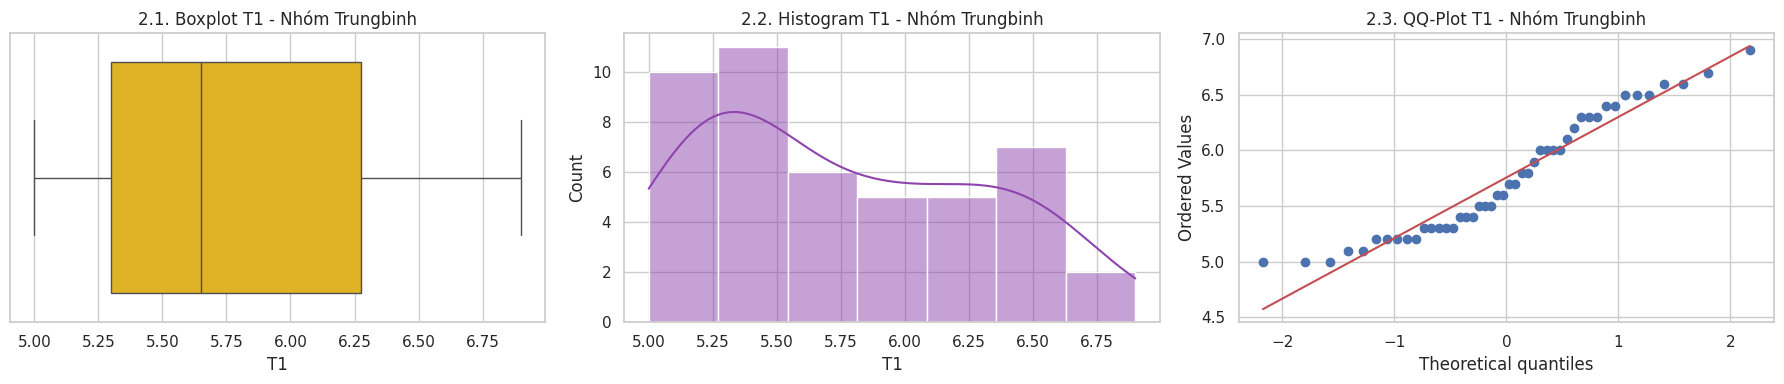


>>> Khảo sát phân phối nhóm phân lớp: Gioi (Số lượng: 12)
    - Biểu đồ Box-Plot, Histogram, QQ-Plot cho nhóm Gioi:


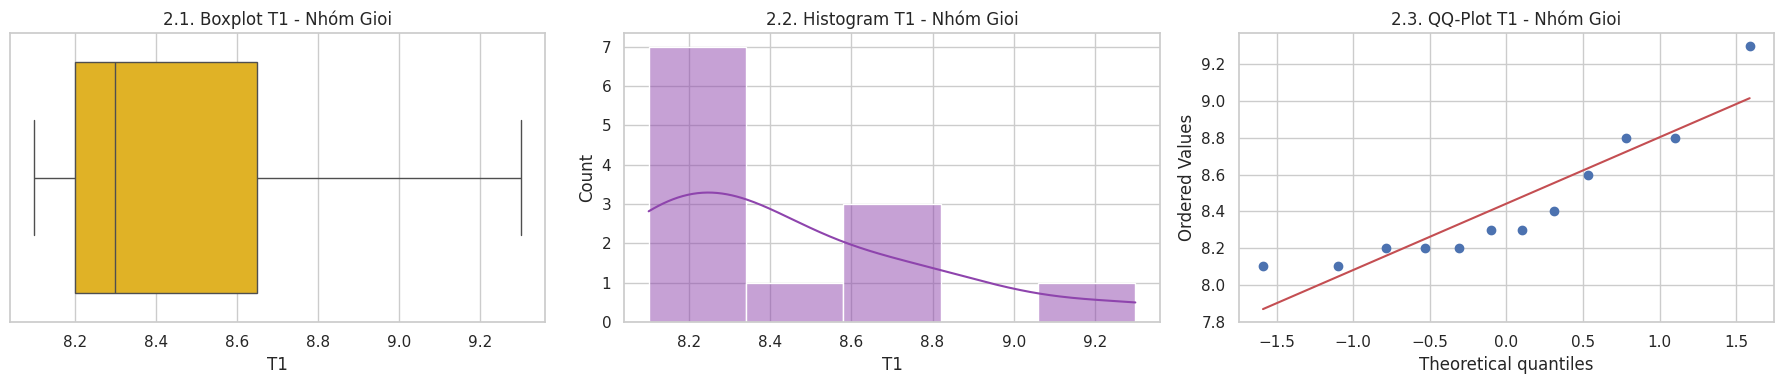


>>> Khảo sát phân phối nhóm phân lớp: Kem (Số lượng: 23)
    - Biểu đồ Box-Plot, Histogram, QQ-Plot cho nhóm Kem:


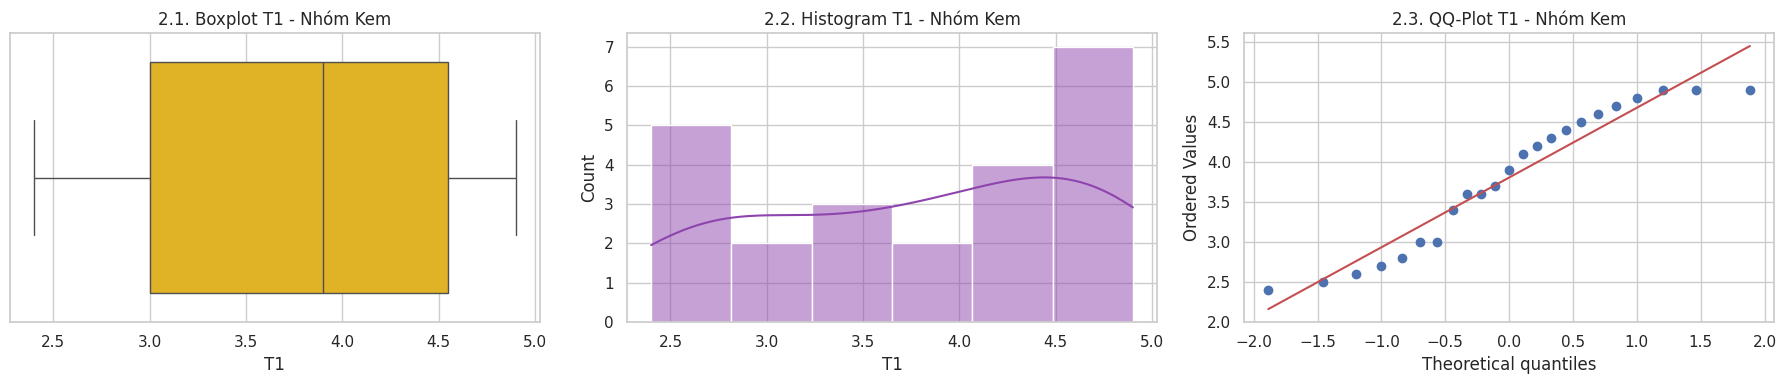


--- KẾT QUẢ CÂU 3: KHẢO SÁT TƯƠNG QUAN GIỮA BIẾN DH1 VÀ T1 ---

3.1. Giá trị hiệp phương sai (Covariance) và hệ số tương quan (Correlation) giữa DH1 và T1:
Hiệp phương sai (Covariance): 0.1128
Hệ số tương quan (Correlation Coefficient): 0.0493
=> Dựa trên hệ số tương quan, ta có thể nhận xét về mức độ và chiều của mối liên hệ.

3.2. Biểu đồ Scatter thể hiện mối liên hệ giữa DH1 (biến phụ thuộc) và T1 (biến độc lập):


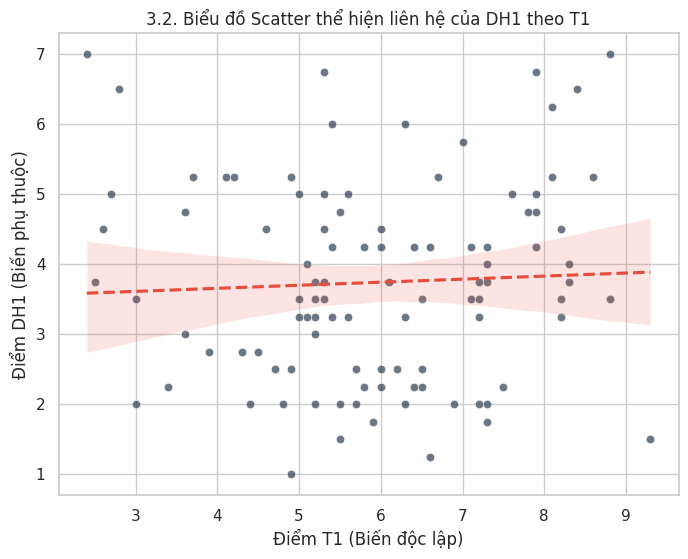


--- KẾT QUẢ CÂU 4: KHẢO SÁT TƯƠNG QUAN GIỮA DH1 VÀ T1 THEO TỪNG NHÓM KHU VỰC ---

4.1. Biểu đồ Scatter thể hiện mối liên hệ giữa DH1 và T1 phân nhóm theo Khu Vực (KV):


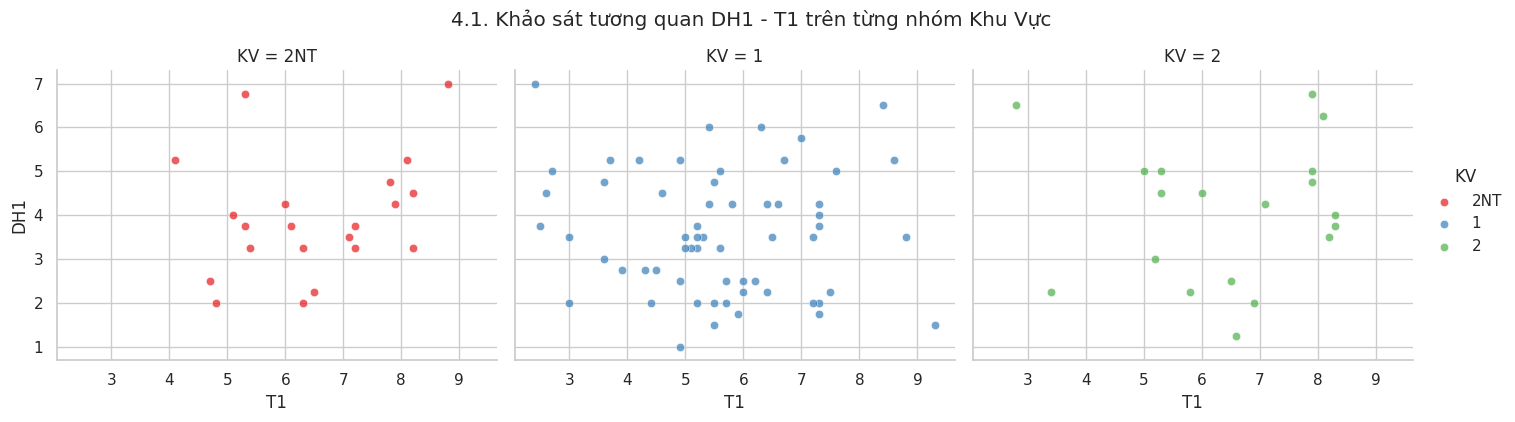


--- KẾT QUẢ CÂU 5: KHẢO SÁT TƯƠNG QUAN GIỮA CÁC BIẾN DH1, DH2, DH3 ---

5.1. Ma trận hiệp phương sai (Covariance Matrix) giữa DH1, DH2, DH3:
          DH1       DH2       DH3
DH1  2.028939  0.053081  0.027778
DH2  0.053081  1.123712 -0.101010
DH3  0.027778 -0.101010  1.083965

5.2. Ma trận tương quan (Correlation Matrix) giữa DH1, DH2, DH3:
          DH1       DH2       DH3
DH1  1.000000  0.035154  0.018731
DH2  0.035154  1.000000 -0.091523
DH3  0.018731 -0.091523  1.000000
=> Ma trận tương quan giúp ta đánh giá mối quan hệ tuyến tính giữa các cặp biến.

5.3. Biểu đồ Scatter Matrix (Pairplot) thể hiện mối liên hệ giữa các cặp biến DH1, DH2, DH3:


<Figure size 1000x800 with 0 Axes>

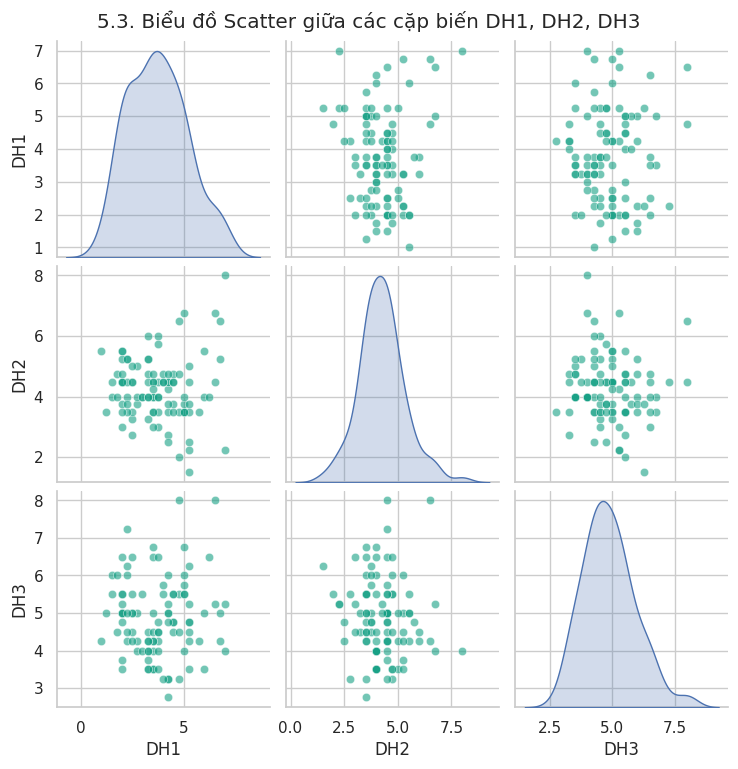

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

print("PHẦN 5: MÔ TẢ DỮ LIỆU & KHẢO SÁT PHÂN PHỐI")
# Gọi tệp dữ liệu sạch ban đầu
df = pd.read_csv('dulieuxettuyendaihoc.csv')

# Thiết lập theme nền trắng có lưới mờ chung cho đồ thị
sns.set_theme(style="whitegrid")


# -------------------------------------------------------------------------
# CÂU 1: Mô tả và khảo sát phân phối cho biến T1
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 1: MÔ TẢ VÀ KHẢO SÁT PHÂN PHỐI CHO BIẾN T1")

# --- Mô tả độ tập trung và phân tán của dữ liệu T1
print("\n1.1. Thống kê mô tả (Descriptive Statistics) của T1:")
desc_t1 = df['T1'].describe()
print(desc_t1)
print(f"Khoảng biến thiên (Range): {desc_t1['max'] - desc_t1['min']}")

# --- Vẽ biểu đồ Box-Plot và xác định các 10 đại lượng trong biểu đồ đó
print("\n1.2. Biểu đồ Box-Plot cho biến T1:")
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['T1'], color='#c3e6cb') # Màu xanh lá nhạt
plt.title('1.2. Biểu đồ Box-Plot của điểm T1')
plt.xlabel('Điểm T1')
plt.show()
# Chú thích 10 đại lượng: Min, Q1 (25%), Median (50%), Q3 (75%), Max, IQR (Q3-Q1),
# Lower Fence (Q1 - 1.5*IQR), Upper Fence (Q3 + 1.5*IQR), Mean (nếu có vẽ), Outliers (nếu có).

# --- Mô tả hình dáng lệch của phân phối T1 dựa vào các đại lượng hướng tâm
print("\n1.3. Khảo sát hình dáng lệch của phân phối T1:")
mean_t1 = desc_t1['mean']
median_t1 = desc_t1['50%']
skew_t1 = df['T1'].skew()
print(f"Giá trị trung bình (Mean): {mean_t1:.4f}")
print(f"Giá trị trung vị (Median): {median_t1:.4f}")
print(f"Hệ số độ lệch (Skewness): {skew_t1:.4f}")
if skew_t1 > 0:
    print("=> Phân phối lệch phải (Right-skewed/Positively skewed).")
elif skew_t1 < 0:
    print("=> Phân phối lệch trái (Left-skewed/Negatively skewed).")
else:
    print("=> Phân phối đối xứng.")

# --- Vẽ biểu đồ Histogram biểu thị hình dáng phân phối
print("\n1.4. Biểu đồ Histogram biểu thị hình dáng phân phối của T1:")
plt.figure(figsize=(10, 5))
sns.histplot(df['T1'], kde=True, color='#007bff', bins=12) # Màu xanh dương
plt.title('1.4. Biểu đồ Histogram hình dáng phân phối của điểm T1')
plt.xlabel('Điểm T1')
plt.ylabel('Tần suất (Count)')
plt.show()

# --- Mô tả các đặc trưng của phân phối, mức độ lệch và mức độ nhọn
print("\n1.5. Khảo sát mức độ nhọn của phân phối:")
kurtosis_t1 = df['T1'].kurt()
print(f"Hệ số độ nhọn (Kurtosis): {kurtosis_t1:.4f}")
if kurtosis_t1 > 0:
    print("=> Phân phối nhọn hơn phân phối chuẩn (Leptokurtic).")
elif kurtosis_t1 < 0:
    print("=> Phân phối bẹt hơn phân phối chuẩn (Platykurtic).")
else:
    print("=> Phân phối có độ nhọn tương đương phân phối chuẩn (Mesokurtic).")

# --- Kiểm chứng phân phối chuẩn QQ-Plot
print("\n1.6. Kiểm chứng phân phối chuẩn bằng biểu đồ QQ-Plot cho T1:")
plt.figure(figsize=(8, 6))
stats.probplot(df['T1'], dist="norm", plot=plt)
plt.title('1.6. Biểu đồ QQ-Plot kiểm tra phân phối chuẩn cho điểm T1')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Nhận xét và đánh giá về phân phối của T1
print("\n1.7. Nhận xét và đánh giá về phân phối của T1:")
print("Dựa trên hệ số Skewness, Kurtosis và biểu đồ QQ-Plot, ta có thể đánh giá sơ bộ về phân phối của dữ liệu T1.")


# -------------------------------------------------------------------------
# CÂU 2: Mô tả và khảo sát phân phối cho biến T1 trên từng nhóm phân lớp (phanlopT1)
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 2: MÔ TẢ VÀ KHẢO SÁT PHÂN PHỐI T1 THEO NHÓM PHÂN LỚP (PHANLOPT1)")

# Đảm bảo đã có biến phân loại phanlopt1 từ Phần 4
def phan_lop(diem):
    if diem < 5.0: return 'Kem'
    elif diem < 7.0: return 'Trungbinh'
    elif diem < 8.0: return 'Kha'
    else: return 'Gioi'
df['phanlopt1'] = df['T1'].apply(phan_lop)

for nhom in df['phanlopt1'].unique():
    df_sub = df[df['phanlopt1'] == nhom]
    print(f"\n>>> Khảo sát phân phối nhóm phân lớp: {nhom} (Số lượng: {len(df_sub)})")

    # Chỉ vẽ đồ thị nếu nhóm có đủ dữ liệu kiểm định
    if len(df_sub) > 1:
        # --- Trực quan hóa biểu đồ Box-plot, histogram và QQ-plot theo phân nhóm là giá trị của ‘phanlopT1’
        print(f"    - Biểu đồ Box-Plot, Histogram, QQ-Plot cho nhóm {nhom}:")
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))

        # 2.1. Box-plot
        sns.boxplot(x=df_sub['T1'], ax=axes[0], color='#ffc107') # Màu vàng
        axes[0].set_title(f'2.1. Boxplot T1 - Nhóm {nhom}')

        # 2.2. Histogram
        sns.histplot(df_sub['T1'], kde=True, ax=axes[1], color='#8e44ad') # Màu tím
        axes[1].set_title(f'2.2. Histogram T1 - Nhóm {nhom}')

        # 2.3. QQ-plot
        stats.probplot(df_sub['T1'], dist="norm", plot=axes[2])
        axes[2].set_title(f'2.3. QQ-Plot T1 - Nhóm {nhom}')

        plt.tight_layout()
        plt.show()


# -------------------------------------------------------------------------
# CÂU 3: Khảo sát tương quan giữa biến DH1 theo biến T1
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 3: KHẢO SÁT TƯƠNG QUAN GIỮA BIẾN DH1 VÀ T1")

# --- Nhận xét giá trị Covariance hoặc Correlation
print("\n3.1. Giá trị hiệp phương sai (Covariance) và hệ số tương quan (Correlation) giữa DH1 và T1:")
covariance_dh1_t1 = df['DH1'].cov(df['T1'])
correlation_dh1_t1 = df['DH1'].corr(df['T1'])
print(f"Hiệp phương sai (Covariance): {covariance_dh1_t1:.4f}")
print(f"Hệ số tương quan (Correlation Coefficient): {correlation_dh1_t1:.4f}")
print("=> Dựa trên hệ số tương quan, ta có thể nhận xét về mức độ và chiều của mối liên hệ.")

# --- Vẽ biểu đồ Scatter thể hiện liên hệ của biến phụ thuộc DH1 theo biến độc lập T1
print("\n3.2. Biểu đồ Scatter thể hiện mối liên hệ giữa DH1 (biến phụ thuộc) và T1 (biến độc lập):")
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='T1', y='DH1', alpha=0.7, color='#2c3e50') # Màu xanh đen
# Vẽ đường xu hướng (regression line) màu đỏ
sns.regplot(data=df, x='T1', y='DH1', scatter=False, color='#e74c3c', line_kws={'linestyle':'--'})
plt.title('3.2. Biểu đồ Scatter thể hiện liên hệ của DH1 theo T1')
plt.xlabel('Điểm T1 (Biến độc lập)')
plt.ylabel('Điểm DH1 (Biến phụ thuộc)')
plt.show()


# -------------------------------------------------------------------------
# CÂU 4: Khảo sát tương quan giữa biến DH1 theo biến T1 trên từng nhóm khu vực
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 4: KHẢO SÁT TƯƠNG QUAN GIỮA DH1 VÀ T1 THEO TỪNG NHÓM KHU VỰC")

if 'KV' in df.columns:
    print("\n4.1. Biểu đồ Scatter thể hiện mối liên hệ giữa DH1 và T1 phân nhóm theo Khu Vực (KV):")
    grid = sns.FacetGrid(df, col="KV", hue="KV", palette="Set1", height=4, aspect=1.2)
    grid.map(sns.scatterplot, "T1", "DH1", alpha=0.7)
    grid.add_legend()
    plt.suptitle('4.1. Khảo sát tương quan DH1 - T1 trên từng nhóm Khu Vực', y=1.05)
    plt.show()
else:
    print("\nLưu ý: Không tìm thấy biến 'KV' trong tệp dữ liệu để thực hiện khảo sát.")


# -------------------------------------------------------------------------
# CÂU 5: Khảo sát tương quan giữa các biến DH1, DH2, DH3
# -------------------------------------------------------------------------
print("\nKẾT QUẢ CÂU 5: KHẢO SÁT TƯƠNG QUAN GIỮA CÁC BIẾN DH1, DH2, DH3")

diem_dh = df[['DH1', 'DH2', 'DH3']]

# --- Nhận xét ma trận hiệp phương sai hoặc ma trận tương quan
print("\n5.1. Ma trận hiệp phương sai (Covariance Matrix) giữa DH1, DH2, DH3:")
cov_matrix_dh = diem_dh.cov()
print(cov_matrix_dh)

print("\n5.2. Ma trận tương quan (Correlation Matrix) giữa DH1, DH2, DH3:")
corr_matrix_dh = diem_dh.corr()
print(corr_matrix_dh)
print("=> Ma trận tương quan giúp ta đánh giá mối quan hệ tuyến tính giữa các cặp biến.")

# --- Vẽ biểu đồ Scatter giữa các biến
print("\n5.3. Biểu đồ Scatter Matrix (Pairplot) thể hiện mối liên hệ giữa các cặp biến DH1, DH2, DH3:")
plt.figure(figsize=(10, 8))
# Sử dụng pairplot để vẽ ma trận scatter, DIAG_KIND='KDE' vẽ đường cong phân phối ở đường chéo
sns.pairplot(diem_dh, diag_kind='kde', plot_kws={'alpha': 0.6, 'color': '#16a085'}) # Màu xanh ngọc
plt.suptitle('5.3. Biểu đồ Scatter giữa các cặp biến DH1, DH2, DH3', y=1.02)
plt.show()